# OULAD FE — Sequence Version (Realtime EWS)

**Mục tiêu:** giữ nguyên các feature đã thiết kế trong notebook tabular giữa kỳ,
nhưng tái cấu trúc thành dạng chuỗi theo tuần (causal per-week)
để train LSTM / Transformer cho dự đoán realtime.

**Nguyên tắc:** mỗi feature `f` trong bản tabular → trở thành chuỗi `f(t)` với `t = 0..T_max-1`,
trong đó `f(t)` chỉ dùng data trong `[day 0, day 7*(t+1)-1]` (không leak future).

**Granularity:** Weekly, T_max = ceil(CUTOFF_DAY / 7) = 25 tuần (với CUTOFF_DAY=170).

**Output:**
- `X_static`: demographics + pre-course (không đổi theo thời gian)
- `X_seq`: dynamic weekly features
- `mask`: padding mask
- `y`: binary target

## 0. Setup & Load Data

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
warnings.filterwarnings('ignore')

INPUT_PATH = '/kaggle/input/datasets/anlgrbz/student-demographics-online-education-dataoulad/'  
OUTPUT_PATH = '/kaggle/working/seq_data/'
df_assessments         = pd.read_csv(INPUT_PATH + 'assessments.csv')
df_studentInfo         = pd.read_csv(INPUT_PATH + 'studentInfo.csv')
df_studentAssessment   = pd.read_csv(INPUT_PATH + 'studentAssessment.csv')
df_studentRegistration = pd.read_csv(INPUT_PATH + 'studentRegistration.csv')
df_studentVle          = pd.read_csv(INPUT_PATH + 'studentVle.csv')
df_courses             = pd.read_csv(INPUT_PATH + 'courses.csv')
df_vle                 = pd.read_csv(INPUT_PATH + 'vle.csv')

CUTOFF_DAY = int(df_courses['module_presentation_length'].min())
RANDOM_SEED = 42
WEEK_LEN = 7
T_MAX = int(np.ceil(CUTOFF_DAY / WEEK_LEN))  
print(f'T_MAX (so tuan): {T_MAX}')

# Binary target: 1 = Fail/Withdrawn (can can thiep), 0 = Pass/Distinction
target_map = {'Withdrawn': 1, 'Fail': 1, 'Pass': 0, 'Distinction': 0}
df_studentInfo['target'] = df_studentInfo['final_result'].map(target_map)
print(df_studentInfo['target'].value_counts())

T_MAX (so tuan): 34
target
1    17208
0    15385
Name: count, dtype: int64


In [2]:
# Cleaning giong notebook goc
df_studentRegistration['date_registration'] = pd.to_numeric(
    df_studentRegistration['date_registration'], errors='coerce')
df_studentRegistration['date_registration'] = df_studentRegistration.groupby(
    ['code_module','code_presentation'])['date_registration'].transform(lambda x: x.fillna(x.median()))
if 'date_unregistration' in df_studentRegistration.columns:
    df_studentRegistration = df_studentRegistration.drop(columns=['date_unregistration'])

df_studentInfo['imd_band'] = df_studentInfo['imd_band'].fillna('Unknown')
df_studentInfo['age_band'] = df_studentInfo['age_band'].fillna('Unknown')

if ('week_from' in df_vle.columns) and ('week_to' in df_vle.columns):
    df_vle = df_vle.drop(columns=['week_from','week_to'])

df_studentAssessment['score'] = df_studentAssessment['score'].fillna(0)
print('Tien xu ly xong.')

Tien xu ly xong.


## 1. Static Features (khong doi theo thoi gian)

Day la cac feature da co trong tabular version, **khong thay doi theo tuan**, se broadcast vao moi timestep:
- Demographics: `gender`, `age_band`, `imd_band`, `region`, `highest_education`, `disability`, `studied_credits`, `num_of_prev_attempts`
- Registration: `date_registration`
- Pre-course engagement: `pre_course_clicks`, `pre_course_active_days`, `has_pre_course_activity`
- Context: `code_module`, `code_presentation`, `module_semester`, `semester`

In [3]:
# 1.1 Pre-course engagement (giu nguyen logic notebook goc)
pre_courses_vle = df_studentVle[df_studentVle['date'] < 0].copy()
pre_courses_engagement = pre_courses_vle.groupby(['id_student']).agg(
    pre_course_clicks      = ('sum_click', 'sum'),
    pre_course_active_days = ('date', 'nunique')
).reset_index()

df_studentInfo = df_studentInfo.drop(columns=['pre_course_clicks','pre_course_active_days'], errors='ignore')
df_studentInfo = df_studentInfo.merge(pre_courses_engagement, on='id_student', how='left')
df_studentInfo[['pre_course_clicks','pre_course_active_days']] = \
    df_studentInfo[['pre_course_clicks','pre_course_active_days']].fillna(0)
df_studentInfo['has_pre_course_activity'] = (df_studentInfo['pre_course_active_days'] > 0).astype(int)
print('Pre-course done.')

Pre-course done.


In [4]:
# 1.2 Merge registration + context features
df_static = df_studentInfo.copy()
df_static = df_static.merge(
    df_studentRegistration[['code_module','code_presentation','id_student','date_registration']],
    on=['code_module','code_presentation','id_student'], how='left'
)
df_static['module_semester'] = df_static['code_module'] + '_' + df_static['code_presentation']
df_static['semester']        = df_static['code_presentation'].str[-1]
print('Static shape:', df_static.shape)
df_static.head(3)

Static shape: (32593, 19)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,target,pre_course_clicks,pre_course_active_days,has_pre_course_activity,date_registration,module_semester,semester
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0,98.0,1.0,1,-159.0,AAA_2013J,J
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,0,215.0,7.0,1,-53.0,AAA_2013J,J
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,1,102.0,6.0,1,-92.0,AAA_2013J,J


## 2. Dynamic (Per-Week) Features — Causal

Day la phan CORE cua ban sequence. Moi feature dynamic tai tuan `t` chi dung data trong `[0, 7*(t+1)-1]`.

**Mapping tu tabular -> sequence:**

| Feature tabular (ban cu) | Feature sequence (ban moi)                         |
|--------------------------|----------------------------------------------------|
| `total_clicks`           | `clicks_this_week_t`, `cum_clicks_t`               |
| `active_days`            | `active_days_this_week_t`, `cum_active_days_t`     |
| `max_daily_clicks`       | `max_daily_clicks_t` (trong tuan t)                |
| `median_daily_clicks`    | `median_daily_clicks_t`                            |
| `std_clicks`             | `std_clicks_t`                                     |
| `clicks_per_active_day`  | `clicks_per_active_day_t`                          |
| `active_rate`            | `active_rate_so_far_t`                             |
| `days_since_last_active` | `days_since_last_active_t` (tai cuoi tuan t)       |
| `active_span`            | `active_span_t`                                    |
| `click_slope`            | `click_slope_recent_t` (slope cua tuan [t-3, t])   |
| `click_slope_r2`         | `click_slope_r2_recent_t`                          |
| `clicks_{oucontent,...}` | `clicks_{type}_this_week_t`, `ratio_{type}_t`      |
| `weekend_clicks`         | `weekend_clicks_this_week_t`, `weekend_ratio_t`    |
| `activity_density`       | `activity_density_so_far_t`                        |
| `gap_trend`, `gap_std`   | `gap_trend_t`, `gap_std_t` (causal)                |
| `weighted_score_before_cutoff` | `weighted_score_so_far_t`                    |
| `tma/cma_submission_rate`| `tma/cma_submission_rate_so_far_t`                 |
| `avg_days_before_deadline` | `avg_days_before_deadline_so_far_t`              |
| `n_missing_submission`   | `n_missing_so_far_t`                               |
| `mean_score`             | `mean_score_so_far_t`                              |
| `total_assessments`      | `n_assessments_submitted_so_far_t`                 |

In [5]:
# 2.1 Chuan bi panel: them cot week cho studentVle va studentAssessment

# Filter chi lay data trong khoang [0, CUTOFF_DAY]
vle = df_studentVle[
    (df_studentVle['date'] >= 0) & (df_studentVle['date'] <= CUTOFF_DAY)
].copy()
vle['week'] = vle['date'] // WEEK_LEN  # week 0 = day 0..6
vle['day_of_week'] = vle['date'] % WEEK_LEN  # 0=Mon, 5=Sat, 6=Sun
vle = vle.merge(df_vle[['id_site','activity_type']], on='id_site', how='left')

# Assessment: dung date_submitted (ngay sinh vien submit thuc te) lam moc thoi gian
# Match ban goc: chi giu assessment co deadline <= CUTOFF_DAY (safe_assessments)
sa = df_studentAssessment.merge(
    df_assessments[['id_assessment','code_module','code_presentation','date','weight','assessment_type']],
    on='id_assessment', how='inner'
)
sa['date_assessment'] = pd.to_numeric(sa['date'], errors='coerce')
sa = sa[
    (sa['assessment_type'] != 'Exam') &
    sa['date_assessment'].notna() &
    (sa['date_assessment'] <= CUTOFF_DAY)
].copy()
sa['date_submitted'] = pd.to_numeric(sa['date_submitted'], errors='coerce')
sa = sa.dropna(subset=['date_submitted'])
sa = sa[(sa['date_submitted'] >= 0) & (sa['date_submitted'] <= CUTOFF_DAY)].copy()
sa['week_submitted'] = sa['date_submitted'].astype(int) // WEEK_LEN
sa['days_before_deadline'] = sa['date_assessment'] - sa['date_submitted']

# Total assessments planned per module-presentation (cho submission rate denominator)
df_assessments['date_num'] = pd.to_numeric(df_assessments['date'], errors='coerce')
asmt_safe = df_assessments[
    df_assessments['date_num'].notna() &
    (df_assessments['date_num'] <= CUTOFF_DAY) &
    (df_assessments['assessment_type'] != 'Exam')
].copy()
asmt_safe['deadline_week'] = (asmt_safe['date_num'].astype(int) // WEEK_LEN)

print('vle (filtered+weeked) shape:', vle.shape)
print('sa  (filtered+weeked) shape:', sa.shape)
print('asmt_safe (deadlines) shape:', asmt_safe.shape)

vle (filtered+weeked) shape: (9703061, 9)
sa  (filtered+weeked) shape: (149252, 13)
asmt_safe (deadlines) shape: (168, 8)


In [6]:
# 2.2 Per-week aggregation cua VLE — RAW WEEKLY (chua cumulative)

attempt_keys = ['id_student','code_module','code_presentation']

# Total clicks + days per week
weekly_basic = vle.groupby(attempt_keys + ['week']).agg(
    clicks_this_week        = ('sum_click', 'sum'),
    active_days_this_week   = ('date', 'nunique'),
    max_daily_clicks_week   = ('sum_click', 'max'),
    median_daily_clicks_week= ('sum_click', 'median'),
    std_clicks_week         = ('sum_click', 'std'),
    last_day_in_week        = ('date', 'max'),
).reset_index()
weekly_basic['std_clicks_week'] = weekly_basic['std_clicks_week'].fillna(0)

# Activity-type breakdown per week
activity_types = ['oucontent','forumng','homepage','subpage','url','quiz']
activity_weekly = vle.pivot_table(
    index=attempt_keys + ['week'],
    columns='activity_type', values='sum_click', aggfunc='sum', fill_value=0
).reset_index()
for t in activity_types:
    if t not in activity_weekly.columns:
        activity_weekly[t] = 0
activity_weekly = activity_weekly[attempt_keys + ['week'] + activity_types]
activity_weekly = activity_weekly.rename(columns={t: f'clicks_{t}_week' for t in activity_types})

# Weekend clicks per week
weekend_weekly = vle[vle['day_of_week'].isin([5,6])].groupby(
    attempt_keys + ['week']).agg(weekend_clicks_week=('sum_click','sum')).reset_index()

print('weekly_basic:', weekly_basic.shape)
print('activity_weekly:', activity_weekly.shape)
print('weekend_weekly:', weekend_weekly.shape)

weekly_basic: (555873, 10)
activity_weekly: (555873, 10)
weekend_weekly: (316176, 5)


In [7]:
# 2.3 Per-week aggregation cua ASSESSMENT — RAW WEEKLY

# Dem so bai nop trong tuan, mean score trong tuan, weighted score trong tuan,
# avg days_before_deadline trong tuan
sa_for_agg = sa.copy()
sa_for_agg['weighted_score_contrib'] = sa_for_agg['score'] * sa_for_agg['weight']

asmt_weekly = sa_for_agg.groupby(attempt_keys + ['week_submitted']).agg(
    n_submitted_week        = ('id_assessment', 'count'),
    score_sum_week          = ('score', 'sum'),
    weight_sum_week         = ('weight', 'sum'),
    weighted_score_num_week = ('weighted_score_contrib', 'sum'),
    days_before_deadline_sum_week = ('days_before_deadline', 'sum'),
    days_before_deadline_count_week = ('days_before_deadline', 'count'),
).reset_index().rename(columns={'week_submitted':'week'})

# TMA/CMA submission counts per week (cho submission rate)
asmt_weekly_typed = sa.groupby(attempt_keys + ['week_submitted','assessment_type']).agg(
    n_sub=('id_assessment','count')
).reset_index().rename(columns={'week_submitted':'week'})

asmt_weekly_typed_pivot = asmt_weekly_typed.pivot_table(
    index=attempt_keys + ['week'], columns='assessment_type', values='n_sub', fill_value=0
).reset_index()
for t in ['TMA','CMA']:
    if t not in asmt_weekly_typed_pivot.columns:
        asmt_weekly_typed_pivot[t] = 0
asmt_weekly_typed_pivot = asmt_weekly_typed_pivot.rename(
    columns={'TMA':'n_tma_submitted_week','CMA':'n_cma_submitted_week'})

# Deadlines per (module, presentation, week): expected denominators
asmt_deadlines = asmt_safe.groupby(
    ['code_module','code_presentation','deadline_week','assessment_type']
).size().reset_index(name='n_due')
asmt_deadlines_pivot = asmt_deadlines.pivot_table(
    index=['code_module','code_presentation','deadline_week'],
    columns='assessment_type', values='n_due', fill_value=0
).reset_index().rename(columns={'deadline_week':'week'})
for t in ['TMA','CMA']:
    if t not in asmt_deadlines_pivot.columns:
        asmt_deadlines_pivot[t] = 0
asmt_deadlines_pivot = asmt_deadlines_pivot.rename(
    columns={'TMA':'n_tma_due_week','CMA':'n_cma_due_week'})

print('asmt_weekly:', asmt_weekly.shape)
print('asmt_weekly_typed_pivot:', asmt_weekly_typed_pivot.shape)
print('asmt_deadlines_pivot:', asmt_deadlines_pivot.shape)

asmt_weekly: (135932, 10)
asmt_weekly_typed_pivot: (135932, 6)
asmt_deadlines_pivot: (124, 5)


In [8]:
# 2.4 Tao panel DAY DU: (id_student, code_module, code_presentation, week) cho moi t = 0..T_MAX-1
# Mot so tuan sinh vien khong co activity -> row se co 0 (sau khi fillna)

attempts = df_static[attempt_keys].drop_duplicates().reset_index(drop=True)
weeks_df = pd.DataFrame({'week': np.arange(T_MAX)})
panel = attempts.assign(_k=1).merge(weeks_df.assign(_k=1), on='_k').drop(columns='_k')
print('Panel full grid shape:', panel.shape, f'({len(attempts)} attempts x {T_MAX} weeks)')

Panel full grid shape: (1108162, 4) (32593 attempts x 34 weeks)


In [9]:
# 2.5 Merge cac weekly aggregations vao panel

panel = panel.merge(weekly_basic, on=attempt_keys + ['week'], how='left')
panel = panel.merge(activity_weekly, on=attempt_keys + ['week'], how='left')
panel = panel.merge(weekend_weekly, on=attempt_keys + ['week'], how='left')
panel = panel.merge(asmt_weekly, on=attempt_keys + ['week'], how='left')
panel = panel.merge(asmt_weekly_typed_pivot, on=attempt_keys + ['week'], how='left')
panel = panel.merge(
    asmt_deadlines_pivot,
    on=['code_module','code_presentation','week'], how='left'
)

# Cac cot weekly absolute -> fillna 0 (tuan do khong activity)
weekly_zero_cols = [
    'clicks_this_week','active_days_this_week','max_daily_clicks_week',
    'median_daily_clicks_week','std_clicks_week',
] + [f'clicks_{t}_week' for t in activity_types] + [
    'weekend_clicks_week',
    'n_submitted_week','score_sum_week','weight_sum_week',
    'weighted_score_num_week','days_before_deadline_sum_week','days_before_deadline_count_week',
    'n_tma_submitted_week','n_cma_submitted_week',
    'n_tma_due_week','n_cma_due_week',
]
for c in weekly_zero_cols:
    if c in panel.columns:
        panel[c] = panel[c].fillna(0)

# last_day_in_week: neu khong co thi de NaN (can rieng de compute days_since_last_active)
print('Panel after merge:', panel.shape)
panel.head(3)

Panel after merge: (1108162, 27)


,id_student,code_module,code_presentation,week,clicks_this_week,active_days_this_week,max_daily_clicks_week,median_daily_clicks_week,std_clicks_week,last_day_in_week,...,n_submitted_week,score_sum_week,weight_sum_week,weighted_score_num_week,days_before_deadline_sum_week,days_before_deadline_count_week,n_cma_submitted_week,n_tma_submitted_week,n_cma_due_week,n_tma_due_week
0,11391,AAA,2013J,0,183.0,4.0,76.0,2.0,13.809916,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,11391,AAA,2013J,1,20.0,1.0,16.0,1.5,7.348469,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,11391,AAA,2013J,2,100.0,2.0,27.0,5.0,6.618876,18.0,...,1.0,78.0,10.0,780.0,1.0,1.0,0.0,1.0,0.0,1.0


In [10]:
# 2.6 Tinh cac CUMULATIVE / CAUSAL features qua time
# Tat ca dung .groupby(attempt_keys).cumsum() / expanding() de chi nhin ve qua khu

panel = panel.sort_values(attempt_keys + ['week']).reset_index(drop=True)
gb = panel.groupby(attempt_keys)

# 2.6.a Cumulative clicks/days
panel['cum_clicks']       = gb['clicks_this_week'].cumsum()
panel['cum_active_days']  = gb['active_days_this_week'].cumsum()

# 2.6.b Active rate so far: cum_active_days / total_days_so_far
panel['days_so_far'] = (panel['week'] + 1) * WEEK_LEN   # day budget toi het tuan t
panel['active_rate_so_far'] = panel['cum_active_days'] / panel['days_so_far']

# 2.6.c Clicks per active day (cumulative)
panel['clicks_per_active_day_cum'] = np.where(
    panel['cum_active_days'] > 0,
    panel['cum_clicks'] / panel['cum_active_days'].clip(lower=1),
    0
)

# 2.6.d Days since last active (tai cuoi tuan t)
panel['last_active_day_so_far'] = gb['last_day_in_week'].ffill()
end_of_week_day = (panel['week'] + 1) * WEEK_LEN - 1
panel['days_since_last_active'] = np.where(
    panel['last_active_day_so_far'].notna(),
    end_of_week_day - panel['last_active_day_so_far'],
    end_of_week_day + 1
)

# 2.6.e Active span so far = last_active - first_active
panel['_first_active_day_so_far'] = gb['last_day_in_week'].transform(
    lambda s: s.expanding().min()
)
panel['active_span_so_far'] = (
    panel['last_active_day_so_far'].fillna(0) - panel['_first_active_day_so_far'].fillna(0)
)
panel = panel.drop(columns=['_first_active_day_so_far'])

print('Cumulative core features done.')
panel[['id_student','week','clicks_this_week','cum_clicks',
       'active_rate_so_far','days_since_last_active']].head(10)

Cumulative core features done.


,id_student,week,clicks_this_week,cum_clicks,active_rate_so_far,days_since_last_active
0,3733,0,0.0,0.0,0.0,7.0
1,3733,1,0.0,0.0,0.0,14.0
2,3733,2,0.0,0.0,0.0,21.0
3,3733,3,0.0,0.0,0.0,28.0
4,3733,4,0.0,0.0,0.0,35.0
5,3733,5,0.0,0.0,0.0,42.0
6,3733,6,0.0,0.0,0.0,49.0
7,3733,7,0.0,0.0,0.0,56.0
8,3733,8,0.0,0.0,0.0,63.0
9,3733,9,0.0,0.0,0.0,70.0


In [11]:
# 2.7 Activity-type ratios (cumulative)
for t in activity_types:
    panel[f'cum_clicks_{t}'] = gb[f'clicks_{t}_week'].cumsum()
    panel[f'ratio_{t}_so_far'] = np.where(
        panel['cum_clicks'] > 0,
        panel[f'cum_clicks_{t}'] / panel['cum_clicks'].clip(lower=1),
        0
    )

# Weekend ratio (cumulative)
panel['cum_weekend_clicks'] = gb['weekend_clicks_week'].cumsum()
panel['weekend_ratio_so_far'] = np.where(
    panel['cum_clicks'] > 0,
    panel['cum_weekend_clicks'] / panel['cum_clicks'].clip(lower=1),
    0
)

print('Activity-type ratios + weekend ratio done.')

Activity-type ratios + weekend ratio done.


In [12]:
# 2.8 Recent slope (window 4 tuan gan nhat) — proxy cho click_slope causal
from scipy.stats import linregress

def rolling_slope_r2(series, window=4):
    out_slope = np.zeros(len(series))
    out_r2 = np.zeros(len(series))
    vals = series.values
    for i in range(len(vals)):
        lo = max(0, i - window + 1)
        seg = vals[lo:i+1]
        if len(seg) >= 2 and np.std(seg) > 0 and np.sum(seg) > 0:
            try:
                r = linregress(np.arange(len(seg)), seg)
                out_slope[i] = r.slope
                out_r2[i] = r.rvalue ** 2
            except Exception:
                pass
    return out_slope, out_r2

slopes = np.zeros(len(panel))
r2s    = np.zeros(len(panel))
for keys, idx in tqdm(gb.indices.items(), desc='Slope per attempt'):
    s, r = rolling_slope_r2(panel.loc[idx, 'clicks_this_week'], window=4)
    slopes[idx] = s
    r2s[idx] = r

panel['click_slope_recent']    = slopes
panel['click_slope_r2_recent'] = r2s
print('Recent slope done.')

Slope per attempt: 100%|██████████| 32593/32593 [07:15<00:00, 74.88it/s]

Recent slope done.


In [13]:
# 2.9 Activity density + gap features (causal)
panel['activity_density_so_far'] = np.where(
    panel['active_span_so_far'] > 0,
    panel['cum_active_days'] / panel['active_span_so_far'].clip(lower=1),
    np.where(panel['cum_active_days'] >= 1, 1.0, 0.0)
)

# Gap features can list active days den tuan t -> tinh iteratively
vle_days = vle.groupby(attempt_keys)['date'].apply(lambda x: sorted(set(x.tolist()))).to_dict()

gap_std_arr  = np.zeros(len(panel))
gap_trend_arr= np.zeros(len(panel))

panel_groups = panel.groupby(attempt_keys, sort=False).indices
for keys, idx_list in tqdm(panel_groups.items(), desc='Gap features'):
    days_all = vle_days.get(keys, [])
    sub = panel.loc[idx_list].sort_values('week')
    for row_idx, week_val in zip(sub.index, sub['week'].values):
        eow = (week_val + 1) * WEEK_LEN - 1
        days_so_far = [d for d in days_all if d <= eow]
        if len(days_so_far) >= 2:
            gaps = np.diff(days_so_far)
            gap_std_arr[row_idx]  = float(np.std(gaps, ddof=0))
            if len(gaps) >= 3:
                try:
                    slope, _ = np.polyfit(np.arange(len(gaps)), gaps, 1)
                    gap_trend_arr[row_idx] = slope
                except Exception:
                    pass
panel['gap_std_so_far']   = gap_std_arr
panel['gap_trend_so_far'] = gap_trend_arr
print('Gap features done.')

Gap features: 100%|██████████| 32593/32593 [03:04<00:00, 176.86it/s]

Gap features done.


In [14]:
# 2.10 Cumulative assessment features
panel['cum_n_submitted']         = gb['n_submitted_week'].cumsum()
panel['cum_score_sum']           = gb['score_sum_week'].cumsum()
panel['cum_weight_sum']          = gb['weight_sum_week'].cumsum()
panel['cum_weighted_score_num']  = gb['weighted_score_num_week'].cumsum()
panel['cum_dbd_sum']             = gb['days_before_deadline_sum_week'].cumsum()
panel['cum_dbd_count']           = gb['days_before_deadline_count_week'].cumsum()

panel['cum_n_tma_submitted']     = gb['n_tma_submitted_week'].cumsum()
panel['cum_n_cma_submitted']     = gb['n_cma_submitted_week'].cumsum()
panel['cum_n_tma_due']           = gb['n_tma_due_week'].cumsum()
panel['cum_n_cma_due']           = gb['n_cma_due_week'].cumsum()

# Derived (causal)
panel['mean_score_so_far'] = np.where(
    panel['cum_n_submitted'] > 0,
    panel['cum_score_sum'] / panel['cum_n_submitted'].clip(lower=1),
    0
)
panel['weighted_score_so_far'] = np.where(
    panel['cum_weight_sum'] > 0,
    panel['cum_weighted_score_num'] / panel['cum_weight_sum'].clip(lower=1),
    0
)
panel['has_weighted_score_so_far'] = (panel['weighted_score_so_far'] > 0).astype(int)
panel['avg_days_before_deadline_so_far'] = np.where(
    panel['cum_dbd_count'] > 0,
    panel['cum_dbd_sum'] / panel['cum_dbd_count'].clip(lower=1),
    0
)
panel['tma_submission_rate_so_far'] = np.where(
    panel['cum_n_tma_due'] > 0,
    panel['cum_n_tma_submitted'] / panel['cum_n_tma_due'].clip(lower=1),
    -1
)
panel['cma_submission_rate_so_far'] = np.where(
    panel['cum_n_cma_due'] > 0,
    panel['cum_n_cma_submitted'] / panel['cum_n_cma_due'].clip(lower=1),
    -1
)
panel['n_missing_so_far'] = (
    (panel['cum_n_tma_due'] - panel['cum_n_tma_submitted']).clip(lower=0) +
    (panel['cum_n_cma_due'] - panel['cum_n_cma_submitted']).clip(lower=0)
)
print('Assessment cumulative features done.')

Assessment cumulative features done.


## 3. Feature lists & Encoding

In [15]:
# 3.1 Dynamic feature list cho moi timestep
DYNAMIC_FEATURES = [
    # Raw weekly
    'clicks_this_week','active_days_this_week',
    'max_daily_clicks_week','median_daily_clicks_week','std_clicks_week',
    'weekend_clicks_week','n_submitted_week',
    # Cumulative / so-far
    'cum_clicks','cum_active_days','active_rate_so_far',
    'clicks_per_active_day_cum',
    'days_since_last_active','active_span_so_far',
    'click_slope_recent','click_slope_r2_recent',
    'activity_density_so_far','gap_std_so_far','gap_trend_so_far',
    'weekend_ratio_so_far',
] + [f'ratio_{t}_so_far' for t in activity_types] + [
    'mean_score_so_far','weighted_score_so_far','has_weighted_score_so_far',
    'avg_days_before_deadline_so_far',
    'tma_submission_rate_so_far','cma_submission_rate_so_far',
    'n_missing_so_far','cum_n_submitted',
]
print(f'So dynamic features per timestep: {len(DYNAMIC_FEATURES)}')
print(DYNAMIC_FEATURES)

So dynamic features per timestep: 33
['clicks_this_week', 'active_days_this_week', 'max_daily_clicks_week', 'median_daily_clicks_week', 'std_clicks_week', 'weekend_clicks_week', 'n_submitted_week', 'cum_clicks', 'cum_active_days', 'active_rate_so_far', 'clicks_per_active_day_cum', 'days_since_last_active', 'active_span_so_far', 'click_slope_recent', 'click_slope_r2_recent', 'activity_density_so_far', 'gap_std_so_far', 'gap_trend_so_far', 'weekend_ratio_so_far', 'ratio_oucontent_so_far', 'ratio_forumng_so_far', 'ratio_homepage_so_far', 'ratio_subpage_so_far', 'ratio_url_so_far', 'ratio_quiz_so_far', 'mean_score_so_far', 'weighted_score_so_far', 'has_weighted_score_so_far', 'avg_days_before_deadline_so_far', 'tma_submission_rate_so_far', 'cma_submission_rate_so_far', 'n_missing_so_far', 'cum_n_submitted']


In [16]:
# 3.2 Encode static features (giong tabular notebook goc)
from sklearn.preprocessing import LabelEncoder

education_order = ['No Formal quals','Lower Than A Level','A Level or Equivalent',
                   'HE Qualification','Post Graduate Qualification']
age_order = ['0-35','35-55','55<=']
imd_order = ['0-10%','10-20%','20-30%','30-40%','40-50%',
             '50-60%','60-70%','70-80%','80-90%','90-100%','Unknown']

df_static['highest_education_encoded'] = df_static['highest_education'].map(
    {v:i for i,v in enumerate(education_order)}).fillna(2)
df_static['age_band_encoded'] = df_static['age_band'].map(
    {v:i for i,v in enumerate(age_order)}).fillna(0)
df_static['imd_band_encoded'] = df_static['imd_band'].map(
    {v:i for i,v in enumerate(imd_order)}).fillna(5)
df_static['semester_enc']     = (df_static['semester'] == 'B').astype(int)
df_static['gender_encoded']   = df_static['gender'].map({'M':0,'F':1}).fillna(2).astype(int)
df_static['disability_encoded']= df_static['disability'].map({'N':0,'Y':1}).fillna(2).astype(int)
print('Categorical encoding done.')

Categorical encoding done.


In [17]:
# 3.3 OOT split: hoc ky cuoi cung = test
presentations = sorted(df_static['code_presentation'].unique())
train_semesters = presentations[:-1]
test_semesters  = [presentations[-1]]
print(f'Train cohorts: {train_semesters}')
print(f'Test cohort (OOT): {test_semesters}')

is_train = df_static['code_presentation'].isin(train_semesters)
is_test  = df_static['code_presentation'].isin(test_semesters)
df_static_train = df_static[is_train].copy().reset_index(drop=True)
df_static_test  = df_static[is_test].copy().reset_index(drop=True)
print(f'Train attempts: {len(df_static_train)} | Test attempts: {len(df_static_test)}')

Train cohorts: ['2013B', '2013J', '2014B']
Test cohort (OOT): ['2014J']
Train attempts: 21333 | Test attempts: 11260


In [18]:
# 3.4 Module-semester encoder (fit on train, safe transform test)
le_module = LabelEncoder()
df_static_train['module_semester_encoded'] = le_module.fit_transform(df_static_train['module_semester'])
known = set(le_module.classes_)
df_static_test['module_semester_encoded'] = df_static_test['module_semester'].apply(
    lambda x: le_module.transform([x])[0] if x in known else -1
)

# Region dummies
region_train = pd.get_dummies(df_static_train['region'], prefix='region', drop_first=True).astype(int)
region_test  = pd.get_dummies(df_static_test['region'],  prefix='region', drop_first=True).astype(int)
region_test  = region_test.reindex(columns=region_train.columns, fill_value=0)
df_static_train = pd.concat([df_static_train, region_train], axis=1)
df_static_test  = pd.concat([df_static_test,  region_test],  axis=1)

STATIC_FEATURES = [
    'highest_education_encoded','age_band_encoded','imd_band_encoded',
    'semester_enc','gender_encoded','disability_encoded',
    'module_semester_encoded',
    'studied_credits','num_of_prev_attempts','date_registration',
    'pre_course_clicks','pre_course_active_days','has_pre_course_activity',
] + list(region_train.columns)

print(f'Static features: {len(STATIC_FEATURES)}')
print(STATIC_FEATURES)

Static features: 25
['highest_education_encoded', 'age_band_encoded', 'imd_band_encoded', 'semester_enc', 'gender_encoded', 'disability_encoded', 'module_semester_encoded', 'studied_credits', 'num_of_prev_attempts', 'date_registration', 'pre_course_clicks', 'pre_course_active_days', 'has_pre_course_activity', 'region_East Midlands Region', 'region_Ireland', 'region_London Region', 'region_North Region', 'region_North Western Region', 'region_Scotland', 'region_South East Region', 'region_South Region', 'region_South West Region', 'region_Wales', 'region_West Midlands Region', 'region_Yorkshire Region']


## 4. Convert Panel -> 3D Tensors

Shape:
- `X_seq`: `(N, T_MAX, n_dynamic)`
- `X_static`: `(N, n_static)`
- `mask`: `(N, T_MAX)` — True o vi tri padded (sau tuan cuoi co activity cua attempt do)
- `y`: `(N,)` — binary target

Voi OULAD, moi attempt deu co du T_MAX tuan (do panel grid full), nen mask se all-False luc build.
Mask van can thiet khi **train voi random truncation** (moi epoch random mot `t` de cat sequence).

In [19]:
# 4.1 Build tensors — vectorized version (nhanh hon nhieu so voi loop tung row)

def build_tensors(df_static_split, panel_full, dynamic_cols, static_cols):
    keys_df = df_static_split[attempt_keys].copy()
    keys_df['_order'] = np.arange(len(keys_df))

    # Merge panel voi keys_df de chi giu cac attempt trong split, va dam bao thu tu khop
    sub_panel = panel_full.merge(keys_df, on=attempt_keys, how='inner')
    sub_panel = sub_panel.sort_values(['_order','week']).reset_index(drop=True)

    n = len(keys_df)
    T = T_MAX
    F = len(dynamic_cols)
    X_seq = np.zeros((n, T, F), dtype=np.float32)
    mask  = np.ones((n, T), dtype=bool)

    # Voi panel full grid, moi (order, week) co 1 row -> co the reshape truc tiep
    # neu so row == n*T
    expected = n * T
    if len(sub_panel) == expected:
        arr = sub_panel[dynamic_cols].values.astype(np.float32).reshape(n, T, F)
        X_seq[:] = arr
        # Mask: tat ca False vi panel grid co du moi (attempt, week)
        # (Cac tuan khong co activity da fillna 0)
        mask[:] = False
    else:
        # Fallback: assign row-by-row neu so row khong khop ky vong
        order_arr = sub_panel['_order'].values
        week_arr = sub_panel['week'].values.astype(int)
        feat_arr = sub_panel[dynamic_cols].values.astype(np.float32)
        for i in range(len(sub_panel)):
            X_seq[order_arr[i], week_arr[i]] = feat_arr[i]
            mask[order_arr[i], week_arr[i]] = False

    X_static = df_static_split[static_cols].values.astype(np.float32)
    y = df_static_split['target'].values.astype(np.float32)
    return X_seq, X_static, mask, y

X_seq_train, X_static_train, mask_train, y_train = build_tensors(
    df_static_train, panel, DYNAMIC_FEATURES, STATIC_FEATURES)
X_seq_test, X_static_test, mask_test, y_test = build_tensors(
    df_static_test, panel, DYNAMIC_FEATURES, STATIC_FEATURES)

print(f'X_seq_train: {X_seq_train.shape} | X_static_train: {X_static_train.shape} | y_train: {y_train.shape}')
print(f'X_seq_test:  {X_seq_test.shape}  | X_static_test:  {X_static_test.shape}  | y_test:  {y_test.shape}')
print(f'Mask padded rate (train): {mask_train.mean():.4f}')

X_seq_train: (21333, 34, 33) | X_static_train: (21333, 25) | y_train: (21333,)
X_seq_test:  (11260, 34, 33)  | X_static_test:  (11260, 25)  | y_test:  (11260,)
Mask padded rate (train): 0.0000


In [20]:
# 4.2 Scale: chuan hoa per-feature qua TAT CA timestep cua TRAIN
from sklearn.preprocessing import StandardScaler

N_tr, T, F = X_seq_train.shape
scaler_seq = StandardScaler()
X_seq_train_flat = X_seq_train.reshape(-1, F)
non_pad_train = (~mask_train).reshape(-1)
scaler_seq.fit(X_seq_train_flat[non_pad_train])

def transform_seq(X_seq, mask):
    N, T, F = X_seq.shape
    flat = X_seq.reshape(-1, F)
    flat_scaled = scaler_seq.transform(flat)
    pad_mask = mask.reshape(-1)
    flat_scaled[pad_mask] = 0
    return flat_scaled.reshape(N, T, F).astype(np.float32)

X_seq_train = transform_seq(X_seq_train, mask_train)
X_seq_test  = transform_seq(X_seq_test, mask_test)

scaler_static = StandardScaler()
X_static_train = scaler_static.fit_transform(X_static_train).astype(np.float32)
X_static_test  = scaler_static.transform(X_static_test).astype(np.float32)

print('Scaling done.')
print(f'X_seq_train stats: mean={X_seq_train[~mask_train].mean():.3f}, std={X_seq_train[~mask_train].std():.3f}')

Scaling done.
X_seq_train stats: mean=-0.000, std=1.000


In [21]:
# 4.3 Save numpy files
import os, json
os.makedirs(OUTPUT_PATH, exist_ok=True)
np.save(OUTPUT_PATH + 'X_seq_train.npy', X_seq_train)
np.save(OUTPUT_PATH + 'X_static_train.npy', X_static_train)
np.save(OUTPUT_PATH + 'mask_train.npy', mask_train)
np.save(OUTPUT_PATH + 'y_train.npy', y_train)
np.save(OUTPUT_PATH + 'X_seq_test.npy', X_seq_test)
np.save(OUTPUT_PATH + 'X_static_test.npy', X_static_test)
np.save(OUTPUT_PATH + 'mask_test.npy', mask_test)
np.save(OUTPUT_PATH + 'y_test.npy', y_test)
with open(OUTPUT_PATH + 'feature_meta.json','w') as f:
    json.dump({
        'DYNAMIC_FEATURES': DYNAMIC_FEATURES,
        'STATIC_FEATURES': STATIC_FEATURES,
        'T_MAX': T_MAX,
        'CUTOFF_DAY': CUTOFF_DAY,
        'WEEK_LEN': WEEK_LEN,
    }, f, indent=2)
print('Saved seq_data/ to Drive.')

Saved seq_data/ to Drive.


## 4.4 Export cho modeling

**Format LONG (panel CSV):** moi sinh vien co T_MAX=25 row, moi row la 1 tuan
- `df_train.csv`, `df_test.csv` co cot `(id_student, code_module, code_presentation, week, target, [DYNAMIC_FEATURES], [STATIC_FEATURES])`
- `feature_cols.json` chua list ten cot dynamic + static

**Format TENSOR (numpy):** da save o cell 4.3 — team dung PyTorch doc thang vao DataLoader

In [22]:
# 4.4 Build df_train_long va df_test_long (format panel)

def build_long_format(df_static_split, panel_full, dynamic_cols, static_cols, scaler_seq, scaler_static):
    """
    Tao DataFrame dang long:
    - Moi attempt co T_MAX row (1 row / week)
    - Bao gom ca dynamic (theo tuan) + static (broadcast) + target
    """
    # Lay subset cua panel cho dung cac attempt trong split
    sub_panel = panel_full.merge(
        df_static_split[attempt_keys + ['target']],
        on=attempt_keys, how='inner'
    )

    # Scale dynamic features (dung scaler da fit tren train)
    dyn_scaled = scaler_seq.transform(sub_panel[dynamic_cols].values.astype(np.float32))
    dyn_df = pd.DataFrame(dyn_scaled, columns=dynamic_cols, index=sub_panel.index)

    # Scale static features va broadcast
    static_idx_map = df_static_split.set_index(attempt_keys)[static_cols]
    static_scaled = scaler_static.transform(static_idx_map.values.astype(np.float32))
    static_df = pd.DataFrame(static_scaled, columns=static_cols, index=static_idx_map.index)

    # Merge static (broadcast) vao sub_panel
    sub_panel_out = sub_panel[attempt_keys + ['week','target']].copy()
    sub_panel_out[dynamic_cols] = dyn_df.values

    static_for_merge = static_df.reset_index()
    sub_panel_out = sub_panel_out.merge(static_for_merge, on=attempt_keys, how='left')

    # Sort de team de dung
    sub_panel_out = sub_panel_out.sort_values(attempt_keys + ['week']).reset_index(drop=True)
    return sub_panel_out

df_train_long = build_long_format(
    df_static_train, panel, DYNAMIC_FEATURES, STATIC_FEATURES, scaler_seq, scaler_static
)
df_test_long = build_long_format(
    df_static_test, panel, DYNAMIC_FEATURES, STATIC_FEATURES, scaler_seq, scaler_static
)

print(f'df_train_long shape: {df_train_long.shape}')
print(f'df_test_long shape:  {df_test_long.shape}')
print(f'  -> {len(df_static_train)} train attempts x {T_MAX} weeks = {len(df_static_train)*T_MAX} expected rows')
print(f'  -> {len(df_static_test)} test attempts x {T_MAX} weeks = {len(df_static_test)*T_MAX} expected rows')
df_train_long.head(3)

df_train_long shape: (725322, 63)
df_test_long shape:  (382840, 63)
  -> 21333 train attempts x 34 weeks = 725322 expected rows
  -> 11260 test attempts x 34 weeks = 382840 expected rows


,id_student,code_module,code_presentation,week,target,clicks_this_week,active_days_this_week,max_daily_clicks_week,median_daily_clicks_week,std_clicks_week,...,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region
0,3733,DDD,2013J,0,1,-0.431242,-0.759506,-0.340664,-0.754573,-0.344155,...,-0.333568,-0.242518,-0.317002,-0.327372,-0.261149,3.062021,-0.284461,-0.258167,-0.296792,-0.260534
1,3733,DDD,2013J,1,1,-0.431242,-0.759506,-0.340664,-0.754573,-0.344155,...,-0.333568,-0.242518,-0.317002,-0.327372,-0.261149,3.062021,-0.284461,-0.258167,-0.296792,-0.260534
2,3733,DDD,2013J,2,1,-0.431242,-0.759506,-0.340664,-0.754573,-0.344155,...,-0.333568,-0.242518,-0.317002,-0.327372,-0.261149,3.062021,-0.284461,-0.258167,-0.296792,-0.260534


In [23]:
# 4.5 Build df_train va df_test (format WIDE — 1 row / attempt, giong notebook goc)
# Trong do dynamic features tai TUAN CUOI (t = T_MAX-1) duoc dung lam representative
# Day la format de team modeling khong dung sequence van co the thu nhanh (XGBoost/LightGBM)

def build_wide_last_week(df_long, dynamic_cols, static_cols, t_last):
    """Lay snapshot tai tuan t_last cho moi attempt."""
    snap = df_long[df_long['week'] == t_last].copy()
    # Cot can giu: keys + target + dynamic (renamed bo suffix _so_far) + static
    cols = attempt_keys + ['target'] + dynamic_cols + static_cols
    return snap[cols].reset_index(drop=True)

df_train_wide = build_wide_last_week(df_train_long, DYNAMIC_FEATURES, STATIC_FEATURES, T_MAX - 1)
df_test_wide  = build_wide_last_week(df_test_long,  DYNAMIC_FEATURES, STATIC_FEATURES, T_MAX - 1)

print(f'df_train_wide shape: {df_train_wide.shape}')
print(f'df_test_wide shape:  {df_test_wide.shape}')
df_train_wide.head(3)

df_train_wide shape: (21333, 62)
df_test_wide shape:  (11260, 62)


,id_student,code_module,code_presentation,target,clicks_this_week,active_days_this_week,max_daily_clicks_week,median_daily_clicks_week,std_clicks_week,weekend_clicks_week,...,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region
0,3733,DDD,2013J,1,-0.431242,-0.759506,-0.340664,-0.754573,-0.344155,-0.299097,...,-0.333568,-0.242518,-0.317002,-0.327372,-0.261149,3.062021,-0.284461,-0.258167,-0.296792,-0.260534
1,8462,DDD,2013J,1,-0.431242,-0.759506,-0.340664,-0.754573,-0.344155,-0.299097,...,2.997893,-0.242518,-0.317002,-0.327372,-0.261149,-0.326582,-0.284461,-0.258167,-0.296792,-0.260534
2,11391,AAA,2013J,0,-0.236696,-0.254057,-0.018146,5.207464,0.337534,-0.299097,...,-0.333568,-0.242518,-0.317002,-0.327372,-0.261149,-0.326582,-0.284461,-0.258167,-0.296792,-0.260534


In [24]:
drop_dynamic = [
    # Yếu với target (Pearson < 0.03)
    'gap_std_so_far', 'ratio_url_so_far', 'weekend_clicks_week','std_clicks_week',
    # Collinear cực mạnh — giữ cái mạnh nhất với target trong mỗi nhóm
    'active_days_this_week', 'max_daily_clicks_week', 'median_daily_clicks_week',  # r~1.0 với clicks_this_week
    'active_rate_so_far',   # r=1.00 với cum_active_days
    'cum_clicks',           # r=0.95 với cum_active_days
    'active_span_so_far',   # r=-0.97 với days_since_last_active
    'n_missing_so_far',     # r=-0.92 với tma_submission_rate
]

drop_static = [
    'region_Scotland', 'region_Wales', 'region_East Midlands Region',  # Chi-square p > 0.05
    'gender_encoded', 'disability_encoded',                            # fairness
]
# Cập nhật lại list DYNAMIC_FEATURES và STATIC_FEATURES
DYNAMIC_FEATURES = [f for f in DYNAMIC_FEATURES if f not in drop_dynamic]
STATIC_FEATURES = [f for f in STATIC_FEATURES if f not in drop_static]

In [25]:
# 4.6 SAVE FILES theo format giong notebook goc

import json
output_path = OUTPUT_PATH
os.makedirs(output_path, exist_ok=True)

# === FORMAT 1: LONG (panel) — recommended cho LSTM/Transformer ===
df_train_long.to_csv(output_path + 'df_train_long.csv', index=False)
df_test_long.to_csv(output_path  + 'df_test_long.csv',  index=False)

# === FORMAT 2: WIDE (last week snapshot) — fallback cho team XGBoost ===
df_train_wide.to_csv(output_path + 'df_train.csv', index=False)
df_test_wide.to_csv(output_path  + 'df_test.csv',  index=False)

# === FEATURE COLUMNS (giong format notebook goc) ===
feature_cols = DYNAMIC_FEATURES + STATIC_FEATURES   # tat ca features dung de train
with open(output_path + 'feature_cols.json', 'w') as f:
    json.dump(feature_cols, f, indent=2)

# Chi tiet phan loai cho team de hieu
with open(output_path + 'feature_cols_detail.json', 'w') as f:
    json.dump({
        'all_features': feature_cols,
        'dynamic_features': DYNAMIC_FEATURES,   # bien theo tuan
        'static_features': STATIC_FEATURES,     # khong bien theo tuan
        'attempt_keys': attempt_keys,
        'target_col': 'target',
        'time_col': 'week',
        'T_MAX': T_MAX,
        'CUTOFF_DAY': CUTOFF_DAY,
        'WEEK_LEN': WEEK_LEN,
        'note': 'df_train_long/df_test_long: panel format (1 row per student-week). df_train/df_test: wide format (snapshot tai tuan cuoi).'
    }, f, indent=2)

# Save scaler de team apply len data moi
import pickle
with open(output_path + 'scaler_seq.pkl', 'wb') as f:
    pickle.dump(scaler_seq, f)
with open(output_path + 'scaler_static.pkl', 'wb') as f:
    pickle.dump(scaler_static, f)

print(f'Xuat xong {len(feature_cols)} features vao {output_path}')
print()
print('  --- LONG format (cho LSTM/Transformer) ---')
print('  df_train_long.csv      | (N_train * T_MAX, n_cols)')
print('  df_test_long.csv       | (N_test  * T_MAX, n_cols)')
print('  --- WIDE format (cho XGBoost/LightGBM, snapshot tuan cuoi) ---')
print('  df_train.csv           | (N_train, n_cols)')
print('  df_test.csv            | (N_test,  n_cols)')
print('  --- TENSOR format (.npy, da save o 4.3) ---')
print('  X_seq_train.npy, X_static_train.npy, mask_train.npy, y_train.npy')
print('  X_seq_test.npy,  X_static_test.npy,  mask_test.npy,  y_test.npy')
print('  --- METADATA ---')
print('  feature_cols.json       | list feature names')
print('  feature_cols_detail.json| metadata day du')
print('  feature_meta.json       | T_MAX, CUTOFF_DAY, etc')
print('  scaler_seq.pkl          | StandardScaler cho dynamic')
print('  scaler_static.pkl       | StandardScaler cho static')

Xuat xong 42 features vao /kaggle/working/seq_data/

  --- LONG format (cho LSTM/Transformer) ---
  df_train_long.csv      | (N_train * T_MAX, n_cols)
  df_test_long.csv       | (N_test  * T_MAX, n_cols)
  --- WIDE format (cho XGBoost/LightGBM, snapshot tuan cuoi) ---
  df_train.csv           | (N_train, n_cols)
  df_test.csv            | (N_test,  n_cols)
  --- TENSOR format (.npy, da save o 4.3) ---
  X_seq_train.npy, X_static_train.npy, mask_train.npy, y_train.npy
  X_seq_test.npy,  X_static_test.npy,  mask_test.npy,  y_test.npy
  --- METADATA ---
  feature_cols.json       | list feature names
  feature_cols_detail.json| metadata day du
  feature_meta.json       | T_MAX, CUTOFF_DAY, etc
  scaler_seq.pkl          | StandardScaler cho dynamic
  scaler_static.pkl       | StandardScaler cho static


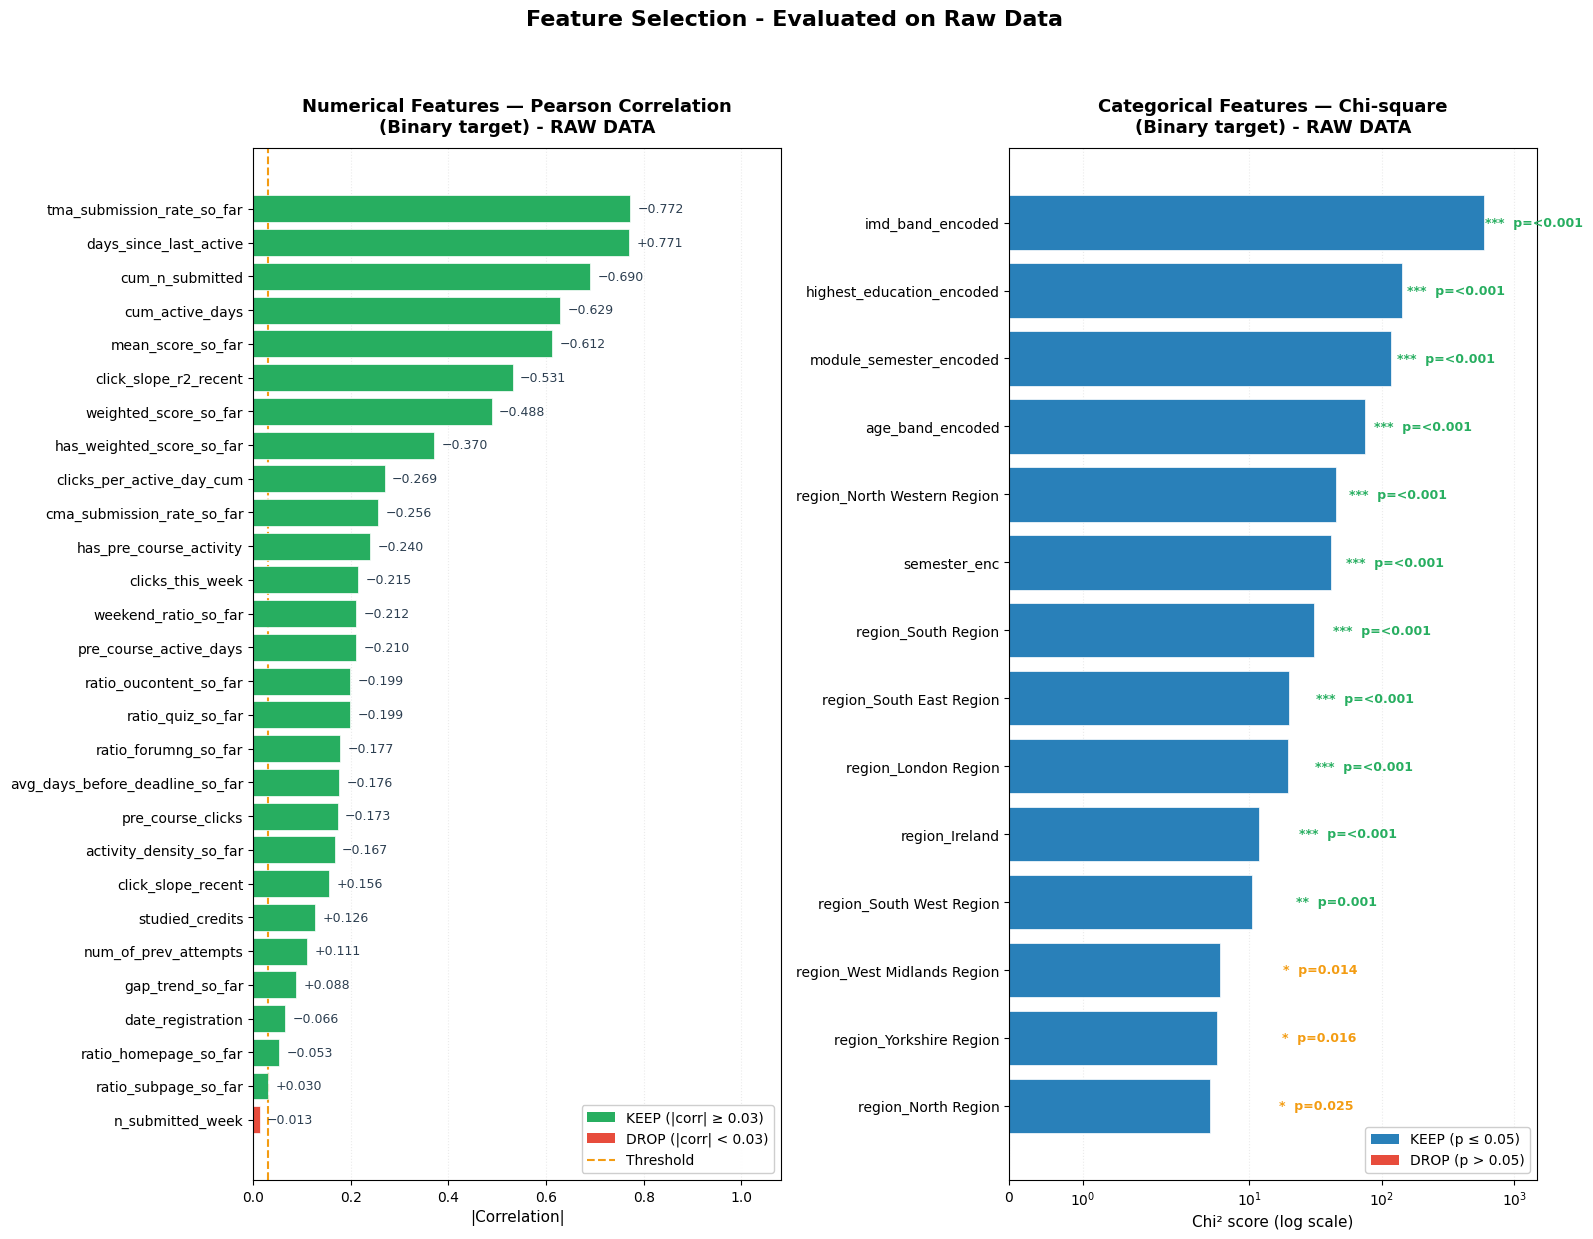

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.feature_selection import chi2
from pandas.api.types import is_numeric_dtype

# ═══════════════════════════════════════════════════════════════════
# 0. TẠO DF_RAW_WIDE TỪ DỮ LIỆU THÔ (RAW) TRƯỚC KHI SCALE
# ═══════════════════════════════════════════════════════════════════
# Lấy snapshot ở tuần cuối cùng (tuần 24) từ bảng panel (chưa bị scale)
t_last = T_MAX - 1
df_raw_wide = panel[panel['week'] == t_last].copy()

# Ghép thêm cột target và các biến static từ df_static_train
df_raw_wide = df_raw_wide.merge(
    df_static_train[attempt_keys + STATIC_FEATURES + ['target']],
    on=attempt_keys,
    how='inner'
)

# ═══════════════════════════════════════════════════════════════════
# 1. PHÂN LOẠI FEATURES (Sử dụng df_raw_wide)
# ═══════════════════════════════════════════════════════════════════
categorical_features = [
    'highest_education_encoded', 'age_band_encoded', 'imd_band_encoded',
    'semester_enc', 'module_semester_encoded'
] + [c for c in feature_cols if c.startswith('region_')]

categorical_features = [f for f in categorical_features if f in df_raw_wide.columns]

numerical_features = [
    f for f in feature_cols
    if f in df_raw_wide.columns
    and is_numeric_dtype(df_raw_wide[f])
    and f not in categorical_features
]

# ═══════════════════════════════════════════════════════════════════
# 2. TÍNH SCORES TRÊN DỮ LIỆU THÔ
# ═══════════════════════════════════════════════════════════════════
y_series = df_raw_wide['target']

# 2.1 Numerical: Pearson correlation
corrs = []
for f in numerical_features:
    c = df_raw_wide[f].corr(y_series)
    if pd.isna(c): c = 0.0
    corrs.append({'feature': f, 'corr': c, 'abs_corr': abs(c)})

df_corr = pd.DataFrame(corrs).sort_values('abs_corr', ascending=True).reset_index(drop=True)

# 2.2 Categorical: Chi-square
X_cat = df_raw_wide[categorical_features].copy().fillna(0)

# Tịnh tiến các giá trị âm để thuật toán Chi2 chạy được
for col in X_cat.columns:
    col_min = X_cat[col].min()
    if col_min < 0:
        X_cat[col] = X_cat[col] - col_min

chi2_scores, chi2_pvals = chi2(X_cat, y_series.astype(int))
df_chi2 = pd.DataFrame({
    'feature': categorical_features,
    'chi2_score': chi2_scores,
    'p_value': chi2_pvals,
}).sort_values('chi2_score', ascending=True).reset_index(drop=True)

# ═══════════════════════════════════════════════════════════════════
# 3. THRESHOLDS
# ═══════════════════════════════════════════════════════════════════
CORR_THRESHOLD = 0.03
P_THRESHOLD = 0.05

# ═══════════════════════════════════════════════════════════════════
# 4. VẼ BIỂU ĐỒ
# ═══════════════════════════════════════════════════════════════════
n_num = len(df_corr)
n_cat = len(df_chi2)
fig_height = max(8, (n_num + n_cat) * 0.3)

fig, axes = plt.subplots(1, 2, figsize=(16, fig_height), gridspec_kw={'width_ratios': [1, 1]})

# ─── Panel A: Numerical — Pearson Correlation ───
ax = axes[0]
colors_num = ['#27ae60' if abs(c) >= CORR_THRESHOLD else '#e74c3c' for c in df_corr['corr']]
bars = ax.barh(df_corr['feature'], df_corr['abs_corr'], color=colors_num, edgecolor='white', linewidth=0.5)
ax.axvline(CORR_THRESHOLD, color='#f39c12', linestyle='--', linewidth=1.5, label=f'Threshold = {CORR_THRESHOLD}', zorder=0)

max_corr = df_corr['abs_corr'].max() if not df_corr.empty else 1
for bar, c in zip(bars, df_corr['corr']):
    sign = '+' if c > 0 else '−'
    ax.text(bar.get_width() + max_corr * 0.02, bar.get_y() + bar.get_height()/2,
            f'{sign}{abs(c):.3f}', va='center', fontsize=9, color='#2c3e50')

ax.set_title('Numerical Features — Pearson Correlation\n(Binary target) - RAW DATA', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('|Correlation|', fontsize=11)
ax.set_xlim(0, max(df_corr['abs_corr']) * 1.4 if not df_corr.empty else 1)
ax.grid(axis='x', alpha=0.25, linestyle=':')
ax.set_axisbelow(True)

legend_a = [
    Patch(facecolor='#27ae60', label=f'KEEP (|corr| ≥ {CORR_THRESHOLD})'),
    Patch(facecolor='#e74c3c', label=f'DROP (|corr| < {CORR_THRESHOLD})'),
    plt.Line2D([0], [0], color='#f39c12', linestyle='--', label='Threshold')
]
ax.legend(handles=legend_a, loc='lower right', fontsize=10, framealpha=0.95)

# ─── Panel B: Categorical — Chi-square ───
ax = axes[1]
colors_cat = ['#2980b9' if p <= P_THRESHOLD else '#e74c3c' for p in df_chi2['p_value']]
bars = ax.barh(df_chi2['feature'], df_chi2['chi2_score'], color=colors_cat, edgecolor='white', linewidth=0.5)

max_chi2 = df_chi2['chi2_score'].max() if not df_chi2.empty else 1
for bar, (_, row) in zip(bars, df_chi2.iterrows()):
    p = row['p_value']
    if p < 0.001:  marker, color = '***', '#27ae60'
    elif p < 0.01: marker, color = '**',  '#27ae60'
    elif p < 0.05: marker, color = '*',   '#f39c12'
    else:          marker, color = 'ns',  '#e74c3c'

    p_str = f'<0.001' if p < 0.001 else f'{p:.3f}'
    ax.text(bar.get_width() + max_chi2 * 0.02, bar.get_y() + bar.get_height()/2,
            f'{marker}  p={p_str}', va='center', fontsize=9,
            color=color, fontweight='bold' if p < 0.05 else 'normal')

ax.set_title('Categorical Features — Chi-square\n(Binary target) - RAW DATA', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Chi² score (log scale)', fontsize=11)

if not df_chi2.empty and df_chi2['chi2_score'].max() > 0:
    ax.set_xscale('symlog')

ax.set_xlim(left=0, right=max_chi2 * 2.5)
ax.grid(axis='x', alpha=0.25, linestyle=':')
ax.set_axisbelow(True)

legend_b = [
    Patch(facecolor='#2980b9', label=f'KEEP (p ≤ {P_THRESHOLD})'),
    Patch(facecolor='#e74c3c', label=f'DROP (p > {P_THRESHOLD})'),
]
ax.legend(handles=legend_b, loc='lower right', fontsize=10, framealpha=0.95)

plt.suptitle('Feature Selection - Evaluated on Raw Data', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

days_since_last_active        0.778457
tma_submission_rate_so_far   -0.778085
click_slope_r2_recent        -0.764496
cum_n_submitted              -0.703022
cum_active_days              -0.687893
mean_score_so_far            -0.622493
clicks_this_week             -0.531807
weighted_score_so_far        -0.513353
has_weighted_score_so_far    -0.370270
weekend_ratio_so_far         -0.323342
Name: target, dtype: float64




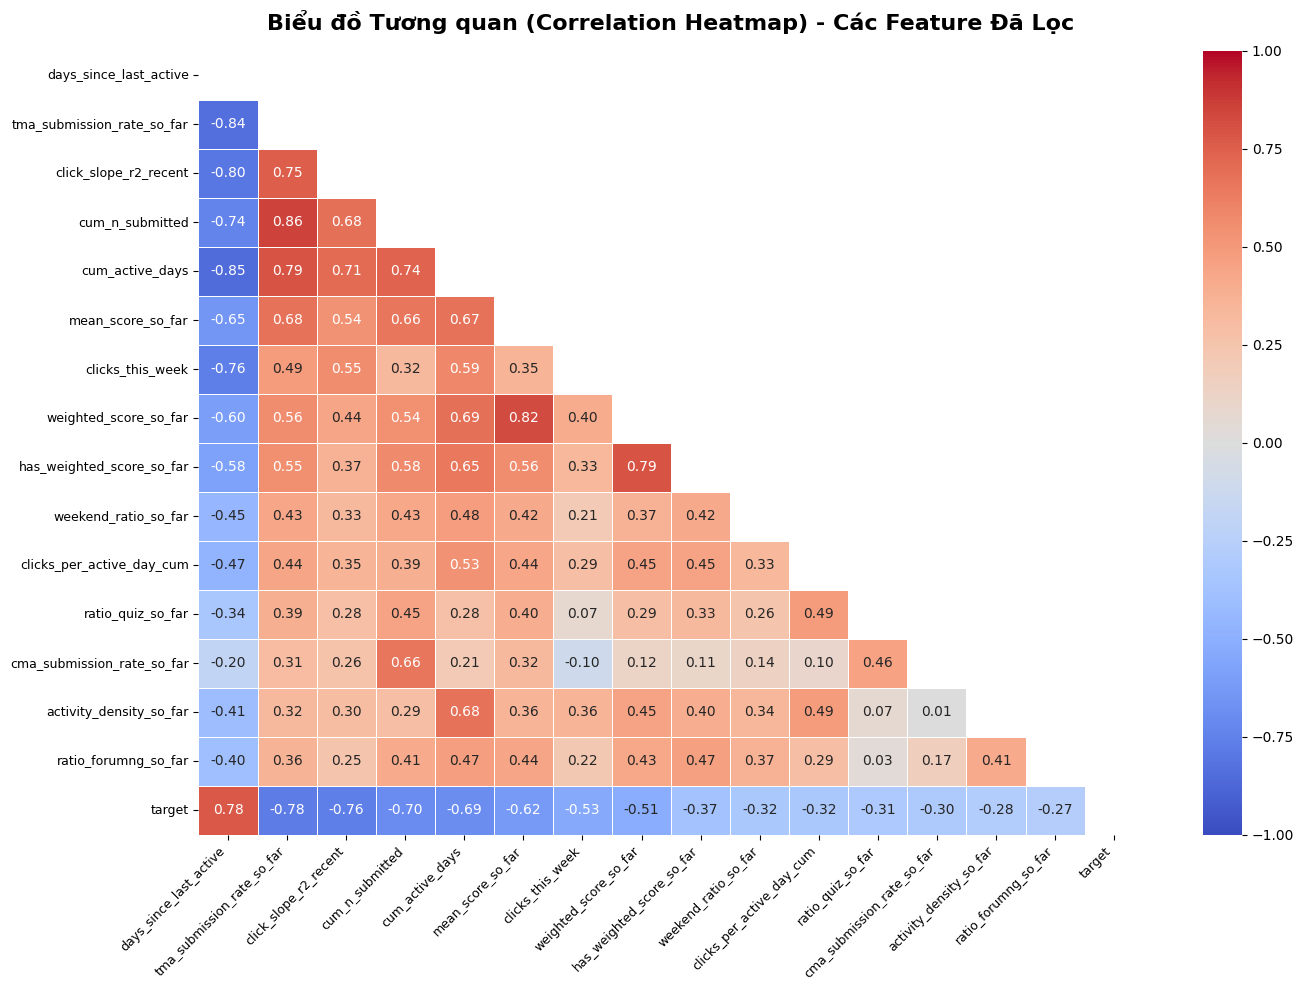

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

corr_cols = DYNAMIC_FEATURES + ['target']
corr_matrix = df_raw_wide[corr_cols].corr(method='spearman')

target_corr = corr_matrix['target'].drop('target').sort_values(key=abs, ascending=False)

print(target_corr.head(10))
print("\n")

# 3. Chọn top 15 features mạnh nhất để vẽ Heatmap
top_15_features = target_corr.head(15).index.tolist()
heatmap_cols = top_15_features + ['target']

# Tạo mask tam giác trên để tránh thông tin trùng lặp
corr_sub = df_raw_wide[heatmap_cols].corr(method='spearman')
mask = np.triu(np.ones_like(corr_sub, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_sub,
            ax=ax,
            mask=mask,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5,
            vmin=-1, vmax=1,
            center=0)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

ax.set_title('Biểu đồ Tương quan (Correlation Heatmap) - Các Feature Đã Lọc', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [28]:
readme_text = f'''# OULAD Sequence Data

## Format files

### LONG format (recommended cho LSTM/Transformer/RNN)
- df_train_long.csv: {len(df_train_long)} rows x {len(df_train_long.columns)} cols
- df_test_long.csv : {len(df_test_long)} rows x {len(df_test_long.columns)} cols
- Moi sinh vien co {T_MAX} row (1 row per week, week 0..{T_MAX-1})
- Cot:
  - Keys: id_student, code_module, code_presentation, week
  - Target: target (0=Pass/Distinction, 1=Fail/Withdrawn)
  - Dynamic features ({len(DYNAMIC_FEATURES)} cot): bien doi theo week
  - Static features ({len(STATIC_FEATURES)} cot): GIONG NHAU o moi week cua cung 1 attempt
- Data da scaled (StandardScaler fit tren train)

### WIDE format (fallback cho XGBoost/LightGBM)
- df_train.csv: {len(df_train_wide)} rows (1 row / attempt, snapshot tai week {T_MAX-1})
- df_test.csv : {len(df_test_wide)} rows

### TENSOR format (cho PyTorch direct)
- X_seq_train.npy: shape ({X_seq_train.shape[0]}, {T_MAX}, {len(DYNAMIC_FEATURES)})
- X_static_train.npy: shape ({X_static_train.shape[0]}, {len(STATIC_FEATURES)})
- mask_train.npy: shape ({X_seq_train.shape[0]}, {T_MAX}) — True = padded
- y_train.npy: shape ({X_seq_train.shape[0]},)
- Tuong tu cho _test

## Cach load (LONG format)

import pandas as pd, json
df_train = pd.read_csv('df_train_long.csv')
df_test  = pd.read_csv('df_test_long.csv')
with open('feature_cols.json') as f:
    feature_cols = json.load(f)
with open('feature_cols_detail.json') as f:
    meta = json.load(f)
dynamic_cols = meta['dynamic_features']
static_cols  = meta['static_features']

# Reshape ve (N, T, F) cho LSTM/Transformer
def to_3d(df, dynamic_cols, T):
    df_sorted = df.sort_values(['id_student','code_module','code_presentation','week'])
    N = len(df_sorted) // T
    return df_sorted[dynamic_cols].values.reshape(N, T, len(dynamic_cols))

X_seq_train = to_3d(df_train, dynamic_cols, T={T_MAX})

## Cach load (TENSOR format - nhanh hon)

import numpy as np
X_seq_train = np.load('X_seq_train.npy')
X_static_train = np.load('X_static_train.npy')
mask_train = np.load('mask_train.npy')
y_train = np.load('y_train.npy')

## Train/Test split
- Train: cac hoc ky tru hoc ky cuoi cung
- Test: hoc ky CUOI CUNG (out-of-time)
- Train cohorts: {train_semesters}
- Test cohort: {test_semesters}

## Causal guarantee
Moi feature dynamic tai tuan t chi dung data trong [day 0, day {WEEK_LEN}*(t+1)-1].
KHONG co data leakage tu tuong lai.

## CUTOFF
CUTOFF_DAY = {CUTOFF_DAY} (~ tuan {T_MAX})
'''

with open(output_path + 'README.md', 'w') as f:
    f.write(readme_text)
print('Saved README.md')
print()
print(readme_text[:1500])

Saved README.md

# OULAD Sequence Data

## Format files

### LONG format (recommended cho LSTM/Transformer/RNN)
- df_train_long.csv: 725322 rows x 63 cols
- df_test_long.csv : 382840 rows x 63 cols
- Moi sinh vien co 34 row (1 row per week, week 0..33)
- Cot:
  - Keys: id_student, code_module, code_presentation, week
  - Target: target (0=Pass/Distinction, 1=Fail/Withdrawn)
  - Dynamic features (22 cot): bien doi theo week
  - Static features (20 cot): GIONG NHAU o moi week cua cung 1 attempt
- Data da scaled (StandardScaler fit tren train)

### WIDE format (fallback cho XGBoost/LightGBM)
- df_train.csv: 21333 rows (1 row / attempt, snapshot tai week 33)
- df_test.csv : 11260 rows

### TENSOR format (cho PyTorch direct)
- X_seq_train.npy: shape (21333, 34, 22)
- X_static_train.npy: shape (21333, 20)
- mask_train.npy: shape (21333, 34) — True = padded
- y_train.npy: shape (21333,)
- Tuong tu cho _test

## Cach load (LONG format)

import pandas as pd, json
df_train = pd.read_csv('df_trai